### Feature Engineering

Cette étape consiste à préparer le jeu de données pour le Machine Learning en définissant la variable cible, en sélectionnant les variables pertinentes et en effectuant les transformations nécessaires. Le dataset obtenu est ainsi prêt pour l'entraînement des modèles.

#### # Chargement des bibliothèques

In [1]:
import pandas as pd 
import sys 
from pathlib import Path 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

#### # Configuration du projet

In [2]:
import sys
from pathlib import Path

# Dossier racine du projet
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(sys.path[:3])

/home/reda/medical-questionnaire-ml
['/home/reda/medical-questionnaire-ml', '/usr/lib/python312.zip', '/usr/lib/python3.12']


#### # Chargement du dataset prétraité

In [3]:
df=pd.read_csv("../data/processed/questionnaire_preprocessed.csv") 

#### # Identification de la variable cible


Dans le cadre de cette étude, l'objectif est de développer un modèle de Machine Learning capable de prédire si les jeux vidéo influencent le temps passé ensemble en famille. Pour cela, il est nécessaire d'identifier la variable cible (Target), c'est-à-dire la variable que le modèle devra prédire, ainsi que les variables explicatives (Features) qui serviront à apprendre les relations existantes au sein des données. Cette étape constitue une phase essentielle du Feature Engineering, car elle définit le problème d'apprentissage et oriente l'ensemble du processus de modélisation


La variable « Les jeux vidéo ont-ils influencé le temps passé ensemble en famille ? » a été choisie comme variable cible, car elle répond directement à l'objectif de l'étude. Les autres variables du questionnaire serviront de variables explicatives pour la prédire.

#### #  Séparation des variables explicatives et de la variable cible

In [4]:
Y=df["Les jeux vidéo ont-ils influencé le temps passé ensemble en famille ?"]
X=df.drop(columns=["Les jeux vidéo ont-ils influencé le temps passé ensemble en famille ?"])

#### # Analyse de la variable cible

In [5]:
# Afficher les différentes classes de la variable cible
print("Classes de la variable cible :")
print(Y.unique())
# Effectif de chaque classe
Y.value_counts()
# Répartition en pourcentage
round(Y.value_counts(normalize=True) * 100, 2)

Classes de la variable cible :
<StringArray>
['Diminué', 'Augmenté', 'Pas de changement']
Length: 3, dtype: str


Les jeux vidéo ont-ils influencé le temps passé ensemble en famille ?
Diminué              60.00
Pas de changement    26.67
Augmenté             13.33
Name: proportion, dtype: float64

#### # Visualisation de variable cible 

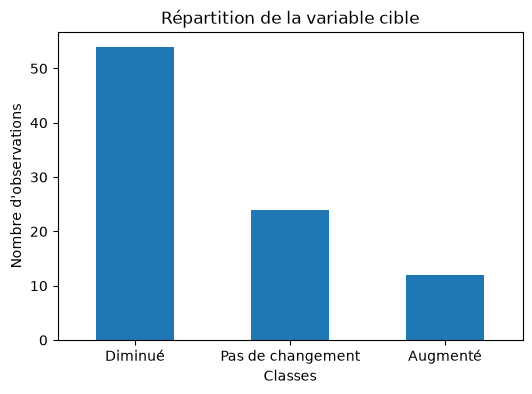

In [ ]:

Y.value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Répartition de la variable cible"
    )

plt.xlabel("Classes")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

#### # Encodage  de variable cible 

##### ## Encodage  

In [7]:
# Initialisation du LabelEncoder
label_encoder = LabelEncoder()

# Encodage de la variable cible
Y = label_encoder.fit_transform(Y)

##### ## Correspondance des classes  de variable cible 

In [8]:
# Correspondance entre les classes et leurs codes
mapping = pd.DataFrame({
    "Classe": label_encoder.classes_,
    "Code": label_encoder.transform(label_encoder.classes_)
})

mapping

,Classe,Code
0,Augmenté,0
1,Diminué,1
2,Pas de changement,2


##### ## Vérification

In [9]:
print("Type :", type(Y))
print("Classes encodées :", set(Y))

Type : <class 'numpy.ndarray'>
Classes encodées : {np.int64(0), np.int64(1), np.int64(2)}


#### # Encodage des variables explicatives

Les variables explicatives du jeu de données sont principalement de nature catégorielle. Afin de les rendre exploitables par les algorithmes de Machine Learning, elles doivent être converties en valeurs numériques. Cette transformation est réalisée à l'aide d'une méthode d'encodage adaptée au type de données.

##### ## Encodage 


In [10]:
from ml.encoder_features import encode_features
X = encode_features(X)

##### ## Validation de d'encodage 

In [12]:
from ml.encoder_features import validate_encoded_dataset
validate_encoded_dataset(X)

VALIDATION DU JEU DE DONNÉES ENCODÉ

Dimensions : (90, 28)

Types des variables :
int64      27
float64     1
Name: count, dtype: int64

Colonnes non encodées :
✔ Toutes les variables sont numériques.

Valeurs manquantes :
✔ Aucune valeur manquante.

Doublons : 0

✅ Le jeu de données est prêt pour l'entraînement des modèles.


#### # Sauvegarder le dataset prêt pour le Machine Learning

In [17]:
X.to_csv("../data/processed/X_encoded.csv", index=False)
pd.DataFrame(Y).to_csv("../data/processed/Y_encoded.csv",index=False)